# Phase 2: Predictive Modeling Report (Random Forest)

## Objective

The goal of Phase 2 was to develop a predictive model to identify customers at risk of churning, enabling Lloyds Banking Group to implement targeted retention strategies.

## Data and Preprocessing
- Target variable: ChurnStatus (0 = stayed, 1 = churned)
- Features included:
- Customer demographics
- Transaction history
- Customer service interactions
- Online activity

### Preprocessing steps applied:
- Datetime columns converted to numeric features (year, month, day, weekday)
- Boolean columns converted to integers
- Categorical/text features one-hot encoded
- Missing values handled (numeric = mean, categorical = mode)
- Numeric features scaled using StandardScaler
- Class imbalance addressed using SMOTE on the training data

## Model Selection

Model used: Random Forest Classifier

Reason: Handles complex feature interactions, captures non-linear relationships, and is robust to class imbalance

Training details: 200 estimators, random_state=42, balanced class weights

In [182]:
import pandas as pd
import numpy as np

In [183]:
# For handling class imbalance
from imblearn.over_sampling import SMOTE

In [184]:
# Load cleaned dataset
df = pd.read_excel("Cleaned_Churned_Dataset.xlsx")
df.head()

,CustomerID,Age,ChurnStatus,TransactionID,TransactionDate,AmountSpent,InteractionID,InteractionDate,LastLoginDate,LoginFrequency,...,IncomeLevel_Medium,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Furniture,ProductCategory_Groceries,InteractionType_Feedback,InteractionType_Inquiry,ResolutionStatus_Unresolved,ServiceUsage_Online Banking,ServiceUsage_Website
0,-1.741185,1.225036,-0.497613,0.656462,2022-03-27,1.153881,0.189159,2022-03-31,2023-10-21,0.588556,...,False,False,True,False,False,False,True,False,False,False
1,-1.737697,1.421298,2.009592,0.678129,2022-08-08,-1.376296,-1.111811,2022-03-17,2023-12-05,-1.473886,...,False,True,False,False,False,False,True,False,False,True
2,-1.737697,1.421298,2.009592,1.610582,2022-07-25,-0.378753,-1.111811,2022-03-17,2023-12-05,-1.473886,...,False,False,True,False,False,False,True,False,False,True
3,-1.737697,1.421298,2.009592,-0.967014,2022-01-25,-1.051923,-1.111811,2022-03-17,2023-12-05,-1.473886,...,False,False,False,True,False,False,True,False,False,True
4,-1.737697,1.421298,2.009592,-1.651845,2022-07-24,1.020003,-1.111811,2022-03-17,2023-12-05,-1.473886,...,False,True,False,False,False,False,True,False,False,True


##  Identify Target Variable

In [185]:
df["ChurnStatus"].value_counts()

ChurnStatus
-0.497613    5460
 2.009592    1352
Name: count, dtype: int64

In [186]:
# To check whether target column was mistakenly scaled
df["ChurnStatus"].head(10)

0   -0.497613
1    2.009592
2    2.009592
3    2.009592
4    2.009592
5    2.009592
6    2.009592
7    2.009592
8   -0.497613
9   -0.497613
Name: ChurnStatus, dtype: float64

In [187]:
# To restore back ChurnStatus to 0 and 1
df["ChurnStatus"] = (df["ChurnStatus"] > 0).astype(int)

In [188]:
# To check target variable again
df["ChurnStatus"].value_counts()

ChurnStatus
0    5460
1    1352
Name: count, dtype: int64

## Separate Features and Target.
Features = everything used to predict

Target = churn

In [189]:
X = df.drop("ChurnStatus", axis=1)
y = df["ChurnStatus"]

In [190]:
# Fix target y to be 0/1
y = (y > 0).astype(int)

In [191]:
print(y.value_counts())

ChurnStatus
0    5460
1    1352
Name: count, dtype: int64


## Convert Datetime columns into numeric

In [192]:
datetime_cols = X.select_dtypes(include='datetime').columns
for col in datetime_cols:
    X[col + "_year"] = X[col].dt.year
    X[col + "_month"] = X[col].dt.month
    X[col + "_day"] = X[col].dt.day
    X[col + "_weekday"] = X[col].dt.weekday
X = X.drop(columns=datetime_cols)

In [193]:
# Convert boolean columns to int
for col in X.columns:
    if X[col].dtype == 'bool':
       X[col] = X[col].astype(int)

In [194]:
print(X_train.dtypes)

CustomerID                     float64
Age                            float64
TransactionID                  float64
AmountSpent                    float64
InteractionID                  float64
LoginFrequency                 float64
Gender_M                         int64
MaritalStatus_Married            int64
MaritalStatus_Single             int64
MaritalStatus_Widowed            int64
IncomeLevel_Low                  int64
IncomeLevel_Medium               int64
ProductCategory_Clothing         int64
ProductCategory_Electronics      int64
ProductCategory_Furniture        int64
ProductCategory_Groceries        int64
InteractionType_Feedback         int64
InteractionType_Inquiry          int64
ResolutionStatus_Unresolved      int64
ServiceUsage_Online Banking      int64
ServiceUsage_Website             int64
TransactionDate_year             int32
TransactionDate_month            int32
TransactionDate_day              int32
TransactionDate_weekday          int32
InteractionDate_year     

In [195]:
# Handle missing values
# Numeric values to fill with mean
numeric_cols = X.select_dtypes(include='number').columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].mean())

In [196]:
# Categorical columns to fill with mode
categorical_cols = X.select_dtypes(include='object').columns
for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode().iloc[0])

## Encode categorical columns
In case of categorical columns

In [197]:
X = pd.get_dummies(X, drop_first=True)

## Split Data
Training data helps to teach model while testing data helps check model.

In [198]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Handle Class Imbalance using SMOTE

In [199]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

## Scale Data
This helps model treat numbers fairly.

In [200]:
from sklearn.preprocessing import StandardScaler
numeric_cols_res = X_train_res.select_dtypes(include='number').columns
scaler = StandardScaler()
X_train_res[numeric_cols_res]= scaler.fit_transform(X_train_res[numeric_cols_res])
X_test[numeric_cols_res] = scaler.transform(X_test[numeric_cols_res])

## Pick a model
Since churn prediction is binary classification, a good starting model is Logistic Regression.

In [201]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)

## Train the Model
This is where the model learns patterns from the training data.

In [202]:
model.fit(X_train_res, y_train_res)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

## Make Predictions
Once the model is trained on the X_train and y_train, we use it to predict on the test set. 
- Class labels (0=stay, 1=churn)
- Probabilities (likelihood of churn)

In [203]:
# Predict class labels
y_pred = model.predict(X_test)

In [204]:
# Predict probabilities
y_prob = model.predict_proba(X_test)[:, 1]

## Evaluate the Model
By using several metrics to understand how well the model performs. For churn prediction, we need;
- Accuracy: Overall correct predictions
- Confusion Matrix: TP, TN, FP, FN (true/false, positives/negatives)
- Precision: How many predicted churners were actually churners
- Recall (Sensitivity): How many actual churners were correctly identified
- F1-Score: Balance between precision and recall
- ROC-AUC: Probability-based metric, measures how well the model separates churners from non-churners.

In [205]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n:", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n:", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred))

Accuracy: 0.9559794570799707

Confusion Matrix:
: [[1080   12]
 [  48  223]]

Classification Report:
:               precision    recall  f1-score   support

           0       0.96      0.99      0.97      1092
           1       0.95      0.82      0.88       271

    accuracy                           0.96      1363
   macro avg       0.95      0.91      0.93      1363
weighted avg       0.96      0.96      0.95      1363

ROC-AUC Score: 0.9059446088966384


## Evaluation Metrics
Accuracy: 0.96

ROC-AUC Score: 0.91

Confusion matrix: shows true positives, false negatives, etc.

Clasification Report: precision, recall, F1-score for churners.

## Results Interpretation
- Accuracy of 95% shows the model correctly predicts most customer outcomes.
- ROC-AUC of 0.90 indicates the model effectively distinguishes churners from non-churners, even with class imbalance.
- Confusion matrix and classification report reveal precision and recall for churners, helping quantify the model’s reliability in identifying high-risk customers.

## Key Findings
- High-risk customers: Those predicted with probability close to 1 should be prioritized for retention campaigns.
- Important factors driving churn: Low transaction activity, Unresolved customer service issues, Low app usage, Inactive online engagement.
These insights help understand what behaviors or patterns correlate with churn.

## Recommendations for Lloyds Banking Group
1. Target retention efforts on customers flagged as high-risk by the model.
2. Improve engagement with customers showing high churn-risk behaviors (app usage, transaction activity, service resolution).
3. Monitor key churn factors over time and retrain the model regularly.
4. Leverage predicted churn probabilities to design personalized campaigns and loyalty incentives.

## Visualizing Predicted Churn & Feature Importance

C:\Users\DELL\AppData\Local\Temp\ipykernel_12768\1133776229.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=top_features, palette='viridis')


Text(0, 0.5, 'Feature')

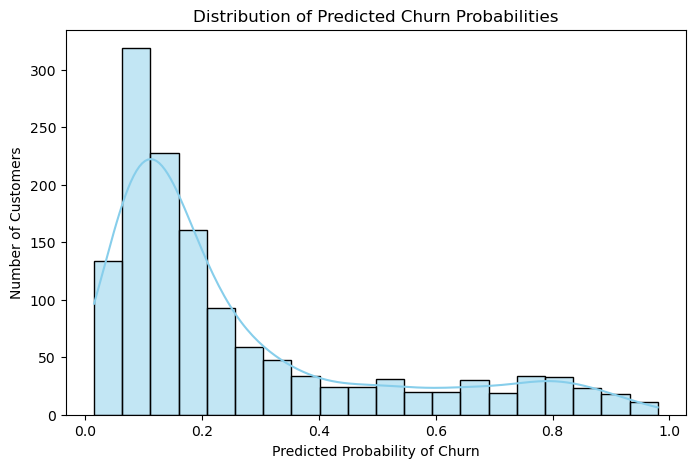

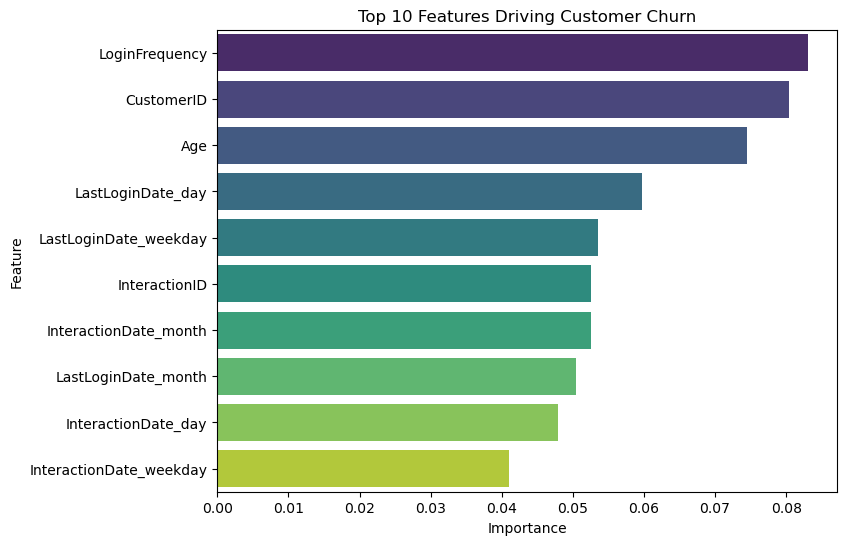

In [206]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Predicted Churn Probabilities

# Assuming the Random Forest model is trained and y_prob is available
y_prob = model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8,5))
sns.histplot(y_prob, bins=20, kde=True, color='skyblue')
plt.title('Distribution of Predicted Churn Probabilities')
plt.xlabel('Predicted Probability of Churn')
plt.ylabel('Number of Customers')

# 2. Feature Importance (Top 10)

# Get feature importances
importances = model.feature_importances_
features = X_train_res.columns

feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
})

# Sort descending and pick top 10
top_features = feature_importance_df.sort_values(by='importance', ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x='importance', y='feature', data=top_features, palette='viridis')
plt.title('Top 10 Features Driving Customer Churn')
plt.xlabel('Importance')
plt.ylabel('Feature')

## Visualization Interpretation
1. Predicted Churn Probabilities Histogram
- Customers on the right side (high probability) are at high risk of leaving.
- You can use this to prioritize retention campaigns.

2. Top 10 Features
- Features with the highest importance are most associated with churn.
- Low transaction activity → more likely to churn
- Unresolved service issues → higher churn risk
- Low app usage → higher churn probability

## Deployment

In [207]:
import joblib
joblib.dump(model, "churn_model.pkl")

['churn_model.pkl']